In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import torch
import umap
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
# from models.deep_multi_encoder import MultiEncoderAutoencoder 
from models.vae import MultiEncoderVAE

/scratch/work/sagara22/newXencoder/.newEnv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata1 = sc.read_h5ad("sq_cell_feature_1.h5ad")
adata2 = sc.read_h5ad("sq_cell_feature_2.h5ad")

In [3]:
X1 = adata1.X.toarray()
X2 = adata2.X.toarray()

In [4]:
X1_tensor = torch.tensor(adata1.X.toarray(), dtype=torch.float32).to("cuda")
X2_tensor = torch.tensor(adata2.X.toarray(), dtype=torch.float32).to("cuda")

In [5]:
latent_dim = 512
hidden_dim = 256
model = MultiEncoderVAE(source_dim=289, target_dim=5001, latent_dim=latent_dim, hidden_dim=hidden_dim)
checkpoint = torch.load("/scratch/work/sagara22/newXencoder/VAE_L512/models/best_model_20250404_064312.pt")
model.load_state_dict(checkpoint)
model.to("cuda")
model.eval()

MultiEncoderVAE(
  (source_encoder): Sequential(
    (0): Linear(in_features=289, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
  )
  (mu_source): Linear(in_features=256, out_features=512, bias=True)
  (logvar_source): Linear(in_features=256, out_features=512, bias=True)
  (target_encoder): Sequential(
    (0): Linear(in_features=5001, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
  )
  (mu_

In [6]:
with torch.no_grad():
    z1, mu1, logvar1 = model.encode_source(X1_tensor)
    z2, mu2, logvar2 = model.encode_target(X2_tensor)

# Move to CPU and convert to numpy
z1 = mu1.cpu().numpy()
z2 = mu2.cpu().numpy()

In [7]:
umap_model1 = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, metric='euclidean')
Z1_umap = umap_model1.fit_transform(z1)

umap_model2 = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, metric='euclidean')
Z2_umap = umap_model2.fit_transform(z2)

In [8]:
# Annotation + Plot (same as before)
leiden1 = adata1.obs["leiden"].astype(str).values
leiden2 = adata2.obs["leiden"].astype(str).values

In [9]:
cl_annotations1 = {
    '1': "Epithelial", '2': "Fibroblasts", '0': "T cells", '3': "Macrophages", '4': "Endothelial",
    '5': "Endothelial", '6': "Smooth muscles", '7': "Epithelial", '8': "Epithelial", '9': "B cells",
    '10': "Epithelial", '11': "Plasma cells", '12': "Epithelial"
}
cl_annotations2 = {
    '1': "Endothelial", '2': "Fibroblasts", '0': "T cells", '4': "Macrophages", '3': "Epithelial",
    '5': "Endothelial", '6': "Epithelial", '7': "Epithelial", '8': "B cells", '9': "Endothelial",
    '10': "Mast cells", '11': "Macrophages"
}

In [10]:
cell_types1 = [f"{cl_annotations1.get(leiden, 'Unknown')} [{leiden}]" for leiden in leiden1]
cell_types2 = [f"{cl_annotations2.get(leiden, 'Unknown')} [{leiden}]" for leiden in leiden2]

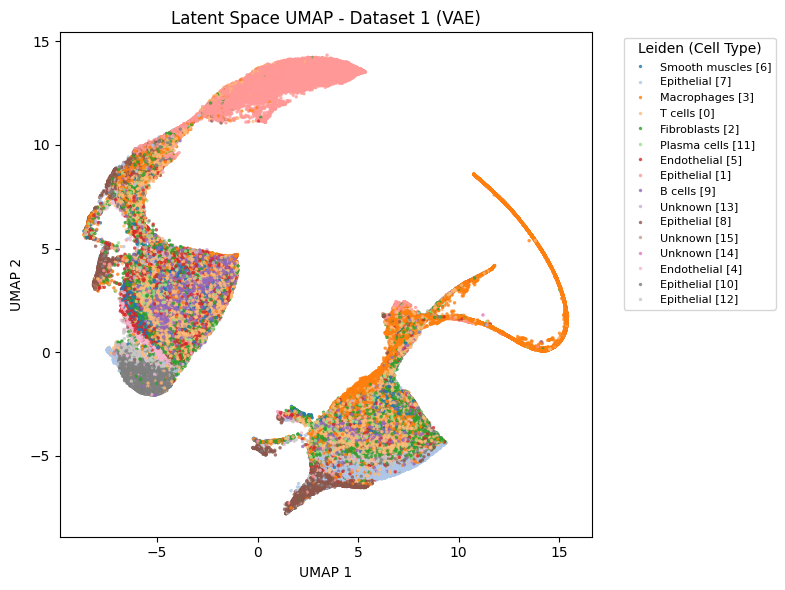

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=Z1_umap[:, 0], y=Z1_umap[:, 1],
    hue=cell_types1, palette="tab20", s=5, alpha=0.8, edgecolor=None
)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Latent Space UMAP - Dataset 1 (VAE)")
plt.legend(title="Leiden (Cell Type)", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('VAE_L384/latent_umap_1.png', dpi=300)
plt.show()

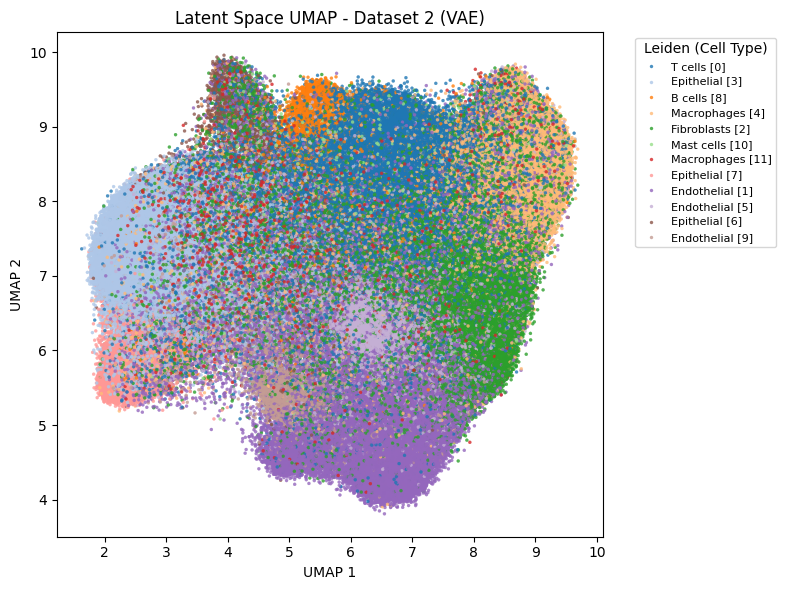

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=Z2_umap[:, 0], y=Z2_umap[:, 1],
    hue=cell_types2, palette="tab20", s=5, alpha=0.8, edgecolor=None
)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Latent Space UMAP - Dataset 2 (VAE)")
plt.legend(title="Leiden (Cell Type)", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('VAE_L384/latent_umap_2.png', dpi=300)
plt.show()